In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master = pd.read_csv("../data_cleaned/m3_master_with_kpis.csv")

master["date"] = pd.to_datetime(master["date"])

display(master.head())
print(master.shape)
print(master.columns)

,base_code,date,year,month_num,new_orders,shipments,unfilled_orders,total_inventories,inventories_to_shipments,unfilled_orders_to_shipments,new_orders_mom_growth,shipments_mom_growth,unfilled_orders_mom_growth,inventories_mom_growth,orders_to_shipments_ratio,inventory_to_shipments_ratio_calc
0,A11A,1992-01-01,1992,1,NaN,3459.0,NaN,3375.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.975716
1,A11A,1992-02-01,1992,2,NaN,3532.0,NaN,3345.0,NaN,NaN,NaN,0.021104,NaN,-0.008889,NaN,0.947055
2,A11A,1992-03-01,1992,3,NaN,3373.0,NaN,3345.0,NaN,NaN,NaN,-0.045017,NaN,0.000000,NaN,0.991699
3,A11A,1992-04-01,1992,4,NaN,3623.0,NaN,3291.0,NaN,NaN,NaN,0.074118,NaN,-0.016143,NaN,0.908363
4,A11A,1992-05-01,1992,5,NaN,3808.0,NaN,3349.0,NaN,NaN,NaN,0.051063,NaN,0.017624,NaN,0.879464


(165096, 16)
Index(['base_code', 'date', 'year', 'month_num', 'new_orders', 'shipments',
       'unfilled_orders', 'total_inventories', 'inventories_to_shipments',
       'unfilled_orders_to_shipments', 'new_orders_mom_growth',
       'shipments_mom_growth', 'unfilled_orders_mom_growth',
       'inventories_mom_growth', 'orders_to_shipments_ratio',
       'inventory_to_shipments_ratio_calc'],
      dtype='str')


In [37]:
series_counts = master.groupby("base_code")["new_orders"].count().sort_values(ascending=False)

display(series_counts.head(20))

base_code
UMN     411
AMN     411
UNXA    410
UNAP    410
UTCG    410
UAN     410
UBTP    410
UNDE    410
UCDG    410
UCMS    410
UITI    410
UDXT    410
UMD     410
UCOG    410
UCRP    410
UDAP    410
UDEF    410
UDXD    410
U36S    410
U36Z    410
Name: new_orders, dtype: int64

In [38]:
target_series = series_counts.index[0]

forecast_data = master[master["base_code"] == target_series].copy()

forecast_data = forecast_data.sort_values("date")
forecast_data = forecast_data[["date", "new_orders"]].dropna()

display(forecast_data.head())
display(forecast_data.tail())

print("Selected base code:", target_series)
print("Rows:", forecast_data.shape[0])

,date,new_orders
155436,1992-01-01,102545.0
155437,1992-02-01,109801.0
155438,1992-03-01,115743.0
155439,1992-04-01,113458.0
155440,1992-05-01,115904.0


,date,new_orders
155842,2025-11-01,289205.0
155843,2025-12-01,292693.0
155844,2026-01-01,282269.0
155845,2026-02-01,281781.0
155846,2026-03-01,323421.0


Selected base code: UMN
Rows: 411


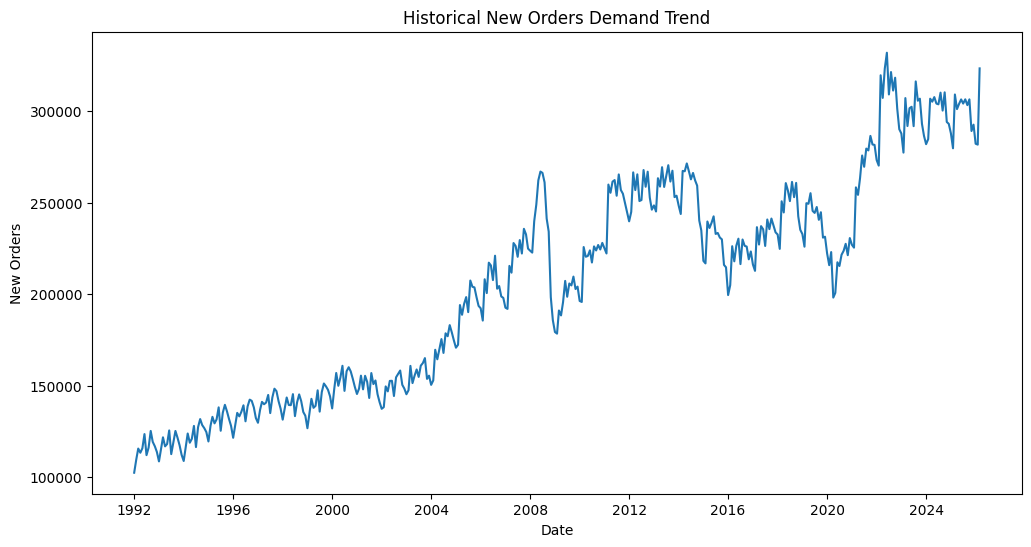

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(forecast_data["date"], forecast_data["new_orders"])
plt.title("Historical New Orders Demand Trend")
plt.xlabel("Date")
plt.ylabel("New Orders")
plt.show()

In [40]:
train = forecast_data.iloc[:-12].copy()
test = forecast_data.iloc[-12:].copy()

print("Train rows:", train.shape[0])
print("Test rows:", test.shape[0])

display(train.tail())
display(test.head())

Train rows: 399
Test rows: 12


,date,new_orders
155830,2024-11-01,294173.0
155831,2024-12-01,293098.0
155832,2025-01-01,287953.0
155833,2025-02-01,279772.0
155834,2025-03-01,309165.0


,date,new_orders
155835,2025-04-01,301184.0
155836,2025-05-01,303973.0
155837,2025-06-01,306474.0
155838,2025-07-01,304200.0
155839,2025-08-01,306520.0


In [41]:
forecast_data["moving_avg_12"] = forecast_data["new_orders"].rolling(window=12).mean()

test = forecast_data.iloc[-12:].copy()

display(test[["date", "new_orders", "moving_avg_12"]])

,date,new_orders,moving_avg_12
155835,2025-04-01,301184.0,300162.833333
155836,2025-05-01,303973.0,299849.083333
155837,2025-06-01,306474.0,300038.250000
155838,2025-07-01,304200.0,300072.333333
155839,2025-08-01,306520.0,299768.833333
155840,2025-09-01,303350.0,300016.666667
155841,2025-10-01,306509.0,299697.583333
155842,2025-11-01,289205.0,299283.583333
155843,2025-12-01,292693.0,299249.833333
155844,2026-01-01,282269.0,298776.166667


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test_eval = test.dropna(subset=["moving_avg_12"]).copy()

mae = mean_absolute_error(test_eval["new_orders"], test_eval["moving_avg_12"])
rmse = np.sqrt(mean_squared_error(test_eval["new_orders"], test_eval["moving_avg_12"]))
mape = np.mean(
    np.abs((test_eval["new_orders"] - test_eval["moving_avg_12"]) / test_eval["new_orders"])
) * 100

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE: 8849.92
RMSE: 10930.07
MAPE: 2.96 %


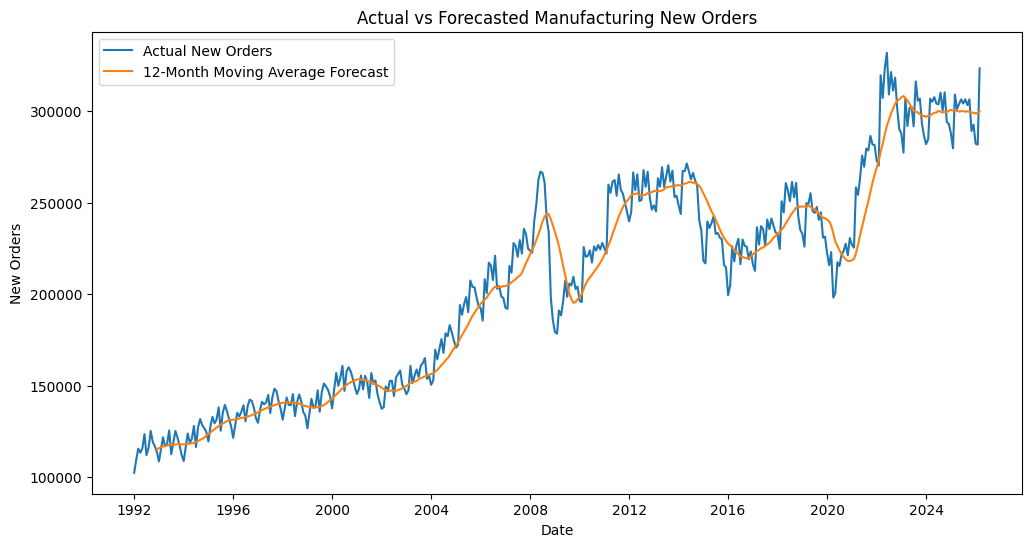

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(
    forecast_data["date"],
    forecast_data["new_orders"],
    label="Actual New Orders"
)

plt.plot(
    forecast_data["date"],
    forecast_data["moving_avg_12"],
    label="12-Month Moving Average Forecast"
)

plt.title("Actual vs Forecasted Manufacturing New Orders")
plt.xlabel("Date")
plt.ylabel("New Orders")
plt.legend()
plt.show()

In [44]:
forecast_output = forecast_data.copy()

forecast_output.to_csv("../outputs/demand_forecast_output.csv", index=False)

print("Demand forecast output saved.")

Demand forecast output saved.


In [45]:
# Create a time index for trend modeling
forecast_data = forecast_data.copy()
forecast_data["time_index"] = range(len(forecast_data))

# Train/test split
train = forecast_data.iloc[:-12].copy()
test = forecast_data.iloc[-12:].copy()

# Fit simple linear trend using numpy
coefficients = np.polyfit(train["time_index"], train["new_orders"], 1)

slope = coefficients[0]
intercept = coefficients[1]

# Predict values
forecast_data["linear_trend_forecast"] = intercept + slope * forecast_data["time_index"]

display(forecast_data.tail(15))

,date,new_orders,moving_avg_12,time_index,linear_trend_forecast
155832,2025-01-01,287953.0,300727.916667,396,294957.507469
155833,2025-02-01,279772.0,300308.750000,397,295424.339568
155834,2025-03-01,309165.0,300499.916667,398,295891.171667
155835,2025-04-01,301184.0,300162.833333,399,296358.003766
155836,2025-05-01,303973.0,299849.083333,400,296824.835865
155837,2025-06-01,306474.0,300038.250000,401,297291.667964
155838,2025-07-01,304200.0,300072.333333,402,297758.500063
155839,2025-08-01,306520.0,299768.833333,403,298225.332162
155840,2025-09-01,303350.0,300016.666667,404,298692.164261
155841,2025-10-01,306509.0,299697.583333,405,299158.996360


In [46]:
test_eval = forecast_data.iloc[-12:].copy()

mae_linear = np.mean(
    np.abs(test_eval["new_orders"] - test_eval["linear_trend_forecast"])
)

rmse_linear = np.sqrt(
    np.mean((test_eval["new_orders"] - test_eval["linear_trend_forecast"]) ** 2)
)

mape_linear = np.mean(
    np.abs((test_eval["new_orders"] - test_eval["linear_trend_forecast"]) / test_eval["new_orders"])
) * 100

print("Linear Trend MAE:", round(mae_linear, 2))
print("Linear Trend RMSE:", round(rmse_linear, 2))
print("Linear Trend MAPE:", round(mape_linear, 2), "%")

Linear Trend MAE: 10432.05
Linear Trend RMSE: 11880.72
Linear Trend MAPE: 3.49 %


In [47]:
model_comparison = pd.DataFrame({
    "Model": ["12-Month Moving Average", "Linear Trend"],
    "MAE": [mae, mae_linear],
    "RMSE": [rmse, rmse_linear],
    "MAPE": [mape, mape_linear]
})

display(model_comparison)

,Model,MAE,RMSE,MAPE
0,12-Month Moving Average,8849.916667,10930.074686,2.961751
1,Linear Trend,10432.054095,11880.718724,3.494012


In [49]:
powerbi_model_comparison = model_comparison.copy()

powerbi_model_comparison["MAE"] = powerbi_model_comparison["MAE"].round(2)
powerbi_model_comparison["RMSE"] = powerbi_model_comparison["RMSE"].round(2)
powerbi_model_comparison["MAPE"] = powerbi_model_comparison["MAPE"].round(2)

powerbi_model_comparison.to_csv("../outputs/powerbi_model_comparison_clean.csv", index=False)

print("Clean Power BI model comparison file saved.")
display(powerbi_model_comparison)

Clean Power BI model comparison file saved.


,Model,MAE,RMSE,MAPE
0,12-Month Moving Average,8849.92,10930.07,2.96
1,Linear Trend,10432.05,11880.72,3.49
